In [311]:
import numpy as np 
import pandas as pd

In [312]:
df=pd.read_csv('spam.csv',encoding='latin1')

In [313]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [314]:
df.shape

(5572, 5)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [316]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [317]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [318]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [319]:
df.sample(5)

,target,text
4127,ham,I dont thnk its a wrong calling between us
3923,ham,How? Izzit still raining?
5324,ham,"Dear Sir,Salam Alaikkum.Pride and Pleasure mee..."
321,ham,Hey... Why dont we just go watch x men and hav...
2276,ham,Love you aathi..love u lot..


In [320]:
from sklearn.preprocessing import LabelEncoder

In [321]:
encoder=LabelEncoder()

In [322]:
df['target']=encoder.fit_transform(df['target'])

In [323]:
df.sample(5)

,target,text
2437,1,For ur chance to win å£250 cash every wk TXT: ...
1617,0,Did u download the fring app?
1366,0,Bbq this sat at mine from 6ish. Ur welcome 2 come
1173,0,ÌÏ dun need to pick ur gf?
3431,1,Camera - You are awarded a SiPix Digital Camer...


In [324]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [325]:
df.duplicated().sum()

np.int64(403)

In [326]:
df=df.drop_duplicates(keep='first')

In [327]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

## EDA

In [328]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [329]:
import matplotlib.pyplot as plt

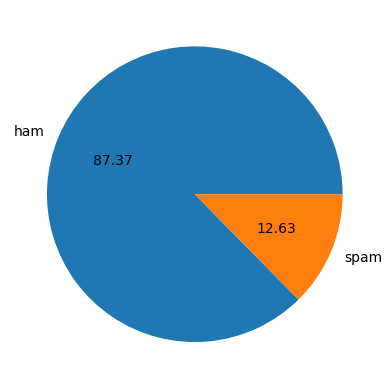

In [330]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%.02f')
plt.show()

In [331]:
import nltk

In [332]:
nltk.word_tokenize("hi how are you.where have you been,call it a day")

['hi',
 'how',
 'are',
 'you.where',
 'have',
 'you',
 'been',
 ',',
 'call',
 'it',
 'a',
 'day']

In [333]:
df['num_characters']=df['text'].apply(len)

In [334]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [335]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [336]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [337]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [338]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [339]:
df.describe()

,target,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [340]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [341]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [342]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

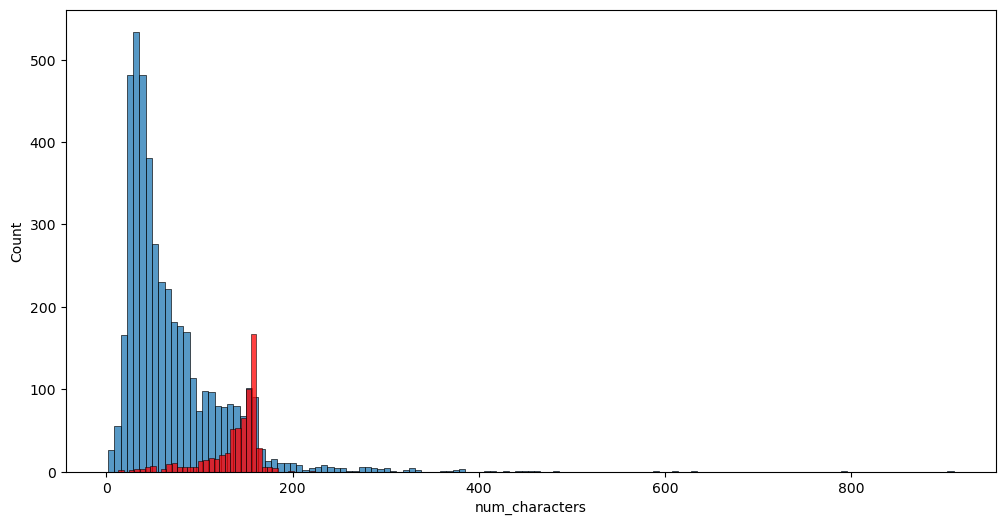

In [343]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

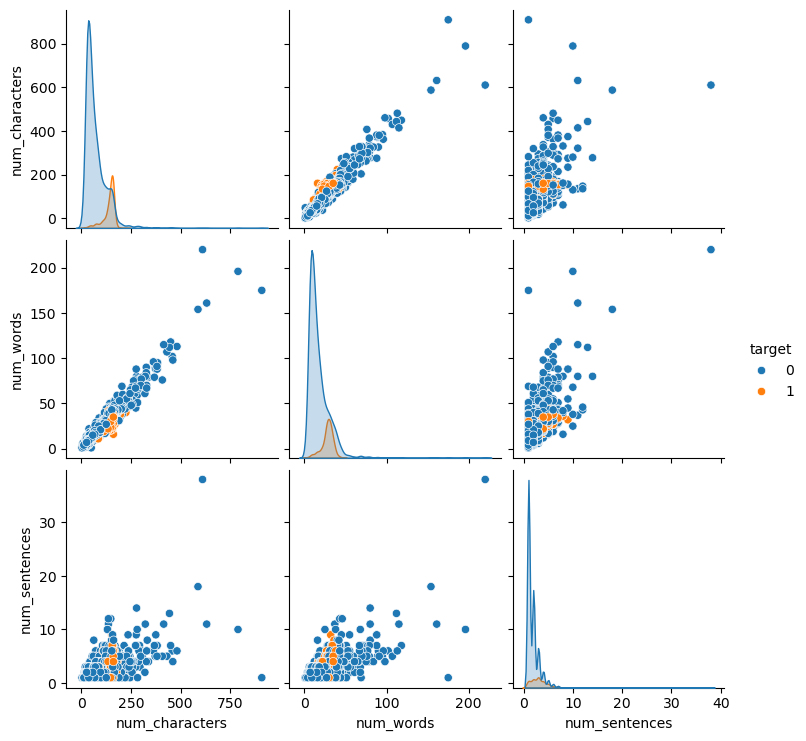

In [344]:
sns.pairplot(df,hue='target')

In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   target          5169 non-null   int64 
 1   text            5169 non-null   object
 2   num_characters  5169 non-null   int64 
 3   num_words       5169 non-null   int64 
 4   num_sentences   5169 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 242.3+ KB


In [346]:
cor=df.corr(numeric_only='True')

<Axes: >

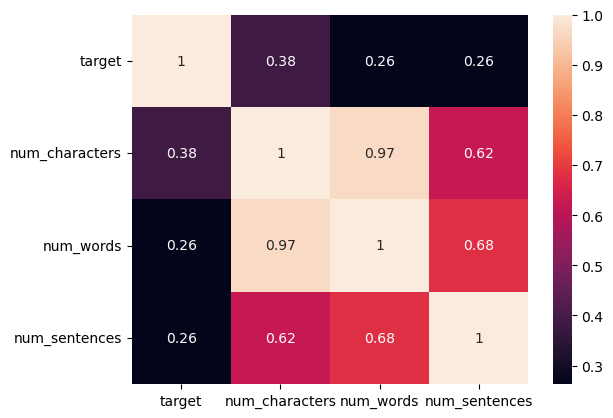

In [347]:
sns.heatmap(cor,annot=True)

## Data Preprocessing

In [348]:
from nltk.corpus import stopwords
stopwords.words('English')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [349]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [350]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [351]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]        
    y.clear()
    for i in text:
        if i not in stopwords.words('English') and i not in string.punctuation:
            y.append(i)
    text=y[:]        
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)       

In [352]:
g=transform_text(df['text'][10])
g

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [353]:
df['transformed_text']=df['text'].apply(transform_text)

In [354]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [355]:
from wordcloud import WordCloud

In [356]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [357]:
wc_spam=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

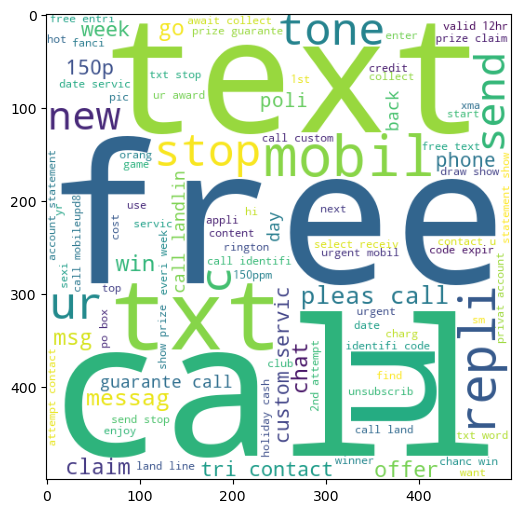

In [358]:
plt.figure(figsize=(6,8))
plt.imshow(wc_spam)

In [359]:
wc_ham=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

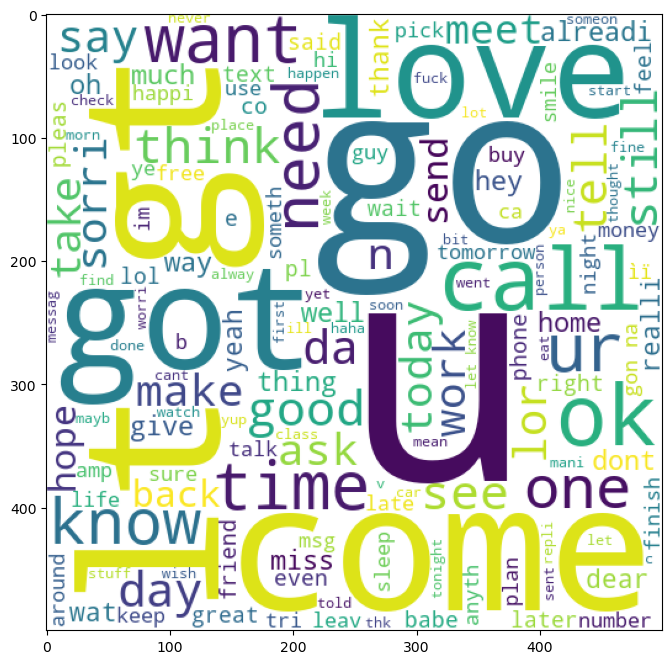

In [360]:
plt.figure(figsize=(10,8))
plt.imshow(wc_spam)

In [361]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [362]:
len(spam_corpus)

9939

In [363]:
from collections import Counter

In [364]:
Counter(spam_corpus).most_common(10)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103)]

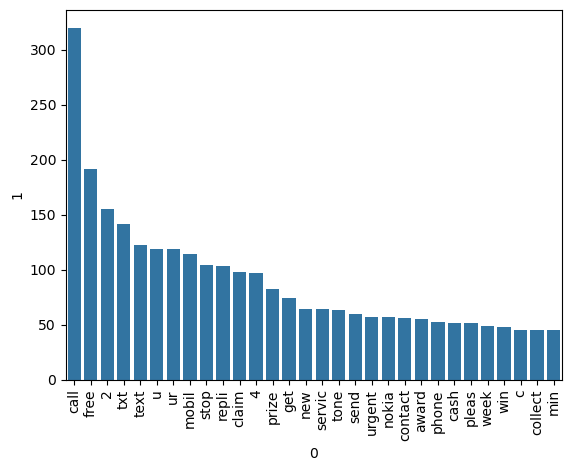

In [365]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [366]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [367]:
len(ham_corpus)

35404

In [368]:
from collections import Counter
Counter(ham_corpus).most_common(10)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234)]

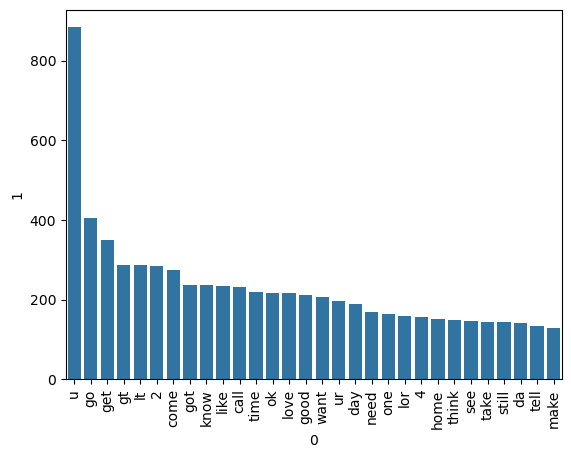

In [369]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

## Model Building

In [370]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [371]:
# cv=CountVectorizer()
# X=cv.fit_transform(df['transformed_text']).toarray()
tfidf=TfidfVectorizer()
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [372]:
X.shape

(5169, 6708)

In [373]:
y=df['target'].values

In [374]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [375]:
from sklearn.model_selection import train_test_split

In [376]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [377]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(4135, 6708) (1034, 6708) (4135,) (1034,)


In [378]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [379]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [380]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [381]:
# gnb.fit(X_train,y_train)
# y_pred1=gnb.predict(X_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [382]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [383]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


## Using Tfidf vectorizer instead of countvectorizer as its giving the best result when we train the model using MUltinomial Naive Bayes model.

## Now testing different models to train and predict the spam to find the best model

In [384]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

def data_Preparation(max_feature=None):
    tfidf=TfidfVectorizer(max_features=max_feature)
    X=tfidf.fit_transform(df['transformed_text']).toarray()
    y=df['target'].values
    return tfidf,X,y    

def data_Spliting(X,y,test_size,random_state):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=test_size,random_state=random_state)
    return X_train,X_test,y_train,y_test
    
tfidf,X,y=data_Preparation()
print(X.shape,y.shape)
X_train,X_test,y_train,y_test=data_Spliting(X,y,0.2,2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5169, 6708) (5169,)
(4135, 6708) (1034, 6708) (4135,) (1034,)


In [385]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [386]:
lr=LogisticRegression(solver='liblinear',penalty='l1')
svc=SVC(kernel='sigmoid',gamma=0.1)
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
knc=KNeighborsClassifier()
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbc=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)


In [387]:
clfs={
    'LR':lr,
    'SVC':svc,
    'NB':mnb,
    'DT':dtc,
    'KN':knc,
    'RF':rfc,
    'AdaBoost':abc,
    'BC':bc,
    'ETC':etc,
    'GBC':gbc,
    'XGB':xgb
}

In [388]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [389]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9110251450676983, 0.9791666666666666)

In [390]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
    print("For ",name)
    print("accuracy ",current_accuracy)
    print("precision ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
accuracy  0.9516441005802708
precision  0.94
For  SVC
accuracy  0.9110251450676983
precision  0.9791666666666666
For  NB
accuracy  0.9593810444874274
precision  1.0
For  DT
accuracy  0.9352030947775629
precision  0.8380952380952381
For  KN
accuracy  0.9003868471953579
precision  1.0
For  RF
accuracy  0.971953578336557
precision  1.0
For  AdaBoost
accuracy  0.9245647969052224
precision  0.8409090909090909
For  BC
accuracy  0.9584139264990329
precision  0.8625954198473282
For  ETC
accuracy  0.9729206963249516
precision  0.9824561403508771
For  GBC
accuracy  0.9526112185686654
precision  0.9238095238095239
For  XGB
accuracy  0.9748549323017408
precision  0.9516129032258065


In [391]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values(by=['Precision','Accuracy'],ascending=[False,False])

In [392]:
performance_df

,Algorithm,Accuracy,Precision
5,RF,0.971954,1.000000
2,NB,0.959381,1.000000
4,KN,0.900387,1.000000
8,ETC,0.972921,0.982456
1,SVC,0.911025,0.979167
10,XGB,0.974855,0.951613
0,LR,0.951644,0.940000
9,GBC,0.952611,0.923810
7,BC,0.958414,0.862595
6,AdaBoost,0.924565,0.840909


In [393]:
performance_df1=pd.melt(performance_df,id_vars='Algorithm')

In [394]:
performance_df1

,Algorithm,variable,value
0,RF,Accuracy,0.971954
1,NB,Accuracy,0.959381
2,KN,Accuracy,0.900387
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.911025
5,XGB,Accuracy,0.974855
6,LR,Accuracy,0.951644
7,GBC,Accuracy,0.952611
8,BC,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


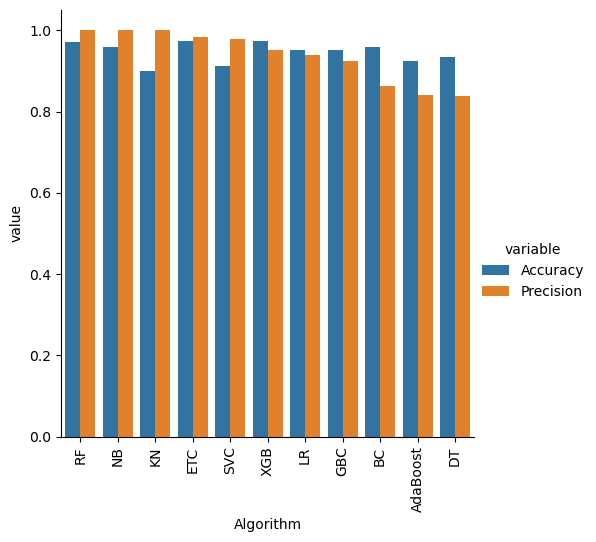

In [395]:
sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar')
plt.xticks(rotation='vertical')
plt.show()

## Model Improvement 
-  Changing the max_features to 3000

In [396]:
tfidf,X,y=data_Preparation(3000)
print(X.shape,y.shape)
X_train,X_test,y_train,y_test=data_Spliting(X,y,0.2,2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5169, 3000) (5169,)
(4135, 3000) (1034, 3000) (4135,) (1034,)


In [397]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
    print("For ",name)
    print("accuracy ",current_accuracy)
    print("precision ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
accuracy  0.9584139264990329
precision  0.9702970297029703
For  SVC
accuracy  0.9294003868471954
precision  0.9710144927536232
For  NB
accuracy  0.9709864603481625
precision  1.0
For  DT
accuracy  0.9274661508704062
precision  0.8118811881188119
For  KN
accuracy  0.9052224371373307
precision  1.0
For  RF
accuracy  0.9758220502901354
precision  0.9829059829059829
For  AdaBoost
accuracy  0.9245647969052224
precision  0.8488372093023255
For  BC
accuracy  0.9584139264990329
precision  0.8682170542635659
For  ETC
accuracy  0.9748549323017408
precision  0.9745762711864406
For  GBC
accuracy  0.9468085106382979
precision  0.9191919191919192
For  XGB
accuracy  0.9671179883945842
precision  0.9482758620689655


In [398]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values(['Precision_max_ft_3000','Accuracy_max_ft_3000'],ascending=[False,False])

In [399]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
2,NB,0.970986,1.000000
4,KN,0.905222,1.000000
5,RF,0.975822,0.982906
8,ETC,0.974855,0.974576
1,SVC,0.929400,0.971014
0,LR,0.958414,0.970297
10,XGB,0.967118,0.948276
9,GBC,0.946809,0.919192
7,BC,0.958414,0.868217
6,AdaBoost,0.924565,0.848837


In [400]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [401]:
new_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,RF,0.971954,1.000000,0.975822,0.982906
1,NB,0.959381,1.000000,0.970986,1.000000
2,KN,0.900387,1.000000,0.905222,1.000000
3,ETC,0.972921,0.982456,0.974855,0.974576
4,SVC,0.911025,0.979167,0.929400,0.971014
5,XGB,0.974855,0.951613,0.967118,0.948276
6,LR,0.951644,0.940000,0.958414,0.970297
7,GBC,0.952611,0.923810,0.946809,0.919192
8,BC,0.958414,0.862595,0.958414,0.868217
9,AdaBoost,0.924565,0.840909,0.924565,0.848837


## Tried to improve the model result by scaling the features

In [402]:
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# X=scaler.fit_transform(X)

In [403]:
# tfidf,X,y=data_Preparation(3000)
# print(X.shape,y.shape)
# X_train,X_test,y_train,y_test=data_Spliting(X,y,0.2,2)
# print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

In [404]:
# accuracy_scores=[]
# precision_scores=[]
# for name,clf in clfs.items():
#     current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
#     print("For ",name)
#     print("accuracy ",current_accuracy)
#     print("precision ",current_precision)

#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

In [405]:
# temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores})

In [406]:
# new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [407]:
# new_df_scaled

## well after trying to improve the model by adding the the max_features to be 3000 and by scaling the fearures using the MinMaxScaler the results didnt improve so we will move with the Random Forest model as it has the precision of 1 and the accuracy score is also the maximum.

-  since we got the best result from Random forest so lets just take it forward.

In [408]:
tfidf,X,y=data_Preparation()
print(X.shape,y.shape)
X_train,X_test,y_train,y_test=data_Spliting(X,y,0.2,2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5169, 6708) (5169,)
(4135, 6708) (1034, 6708) (4135,) (1034,)


In [409]:
train_classifier(rfc,X_train,y_train,X_test,y_test)

(0.971953578336557, 1.0)

In [410]:
rfc.fit(X_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [412]:
predd=rfc.predict(X_test)

In [413]:
print(accuracy_score(y_test,predd),precision_score(y_test,predd))

0.971953578336557 1.0


In [414]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(rfc,open('model.pkl','wb'))